# CSI Feature Analysis: Simulated vs Real

Preliminary feature analysis for HAR (Human Activity Recognition) with RIS-assisted Digital Twin.
Features match exactly those used in `csi_har_benchmark_pt.py` (7 static + 12 Doppler scalars).

| # | Section |
|---|---------|
| 1 | Dataset loading (NPZ, rx0 only for sim) |
| 2 | Static and Doppler feature extraction |
| 3-4 | Feature distributions — violin plots (static / Doppler) |
| 5 | Doppler heatmap (time x subcarrier) |
| 6 | Temporal profiles of rel_env_t |
| 7 | PCA 2D sim vs real |
| 8 | FDR: separability and transferability |
| 9 | Domain gap per feature and class |
| 10 | FALL vs IDLE focus (critical confusion pair) |


In [1]:
import os
import itertools
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':          9,
    'axes.titlesize':    11,
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'legend.fontsize':    8,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'axes.grid':         True,
    'grid.alpha':         0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})


## 0. Configuration

In [2]:
CLASSES = ['FALL', 'IDLE', 'JUMP', 'RUN', 'STAND', 'WALK']
CLASS_COLORS = {
    'FALL':  '#e74c3c',
    'IDLE':  '#3498db',
    'JUMP':  '#1abc9c',
    'RUN':   '#e67e22',
    'STAND': '#2ecc71',
    'WALK':  '#f39c12',
}

OUT_DIR = 'figs/dataset_v2/analysis_plots'
os.makedirs(OUT_DIR, exist_ok=True)

STATIC_FEAT_NAMES = [
    'mean_amp', 'var_amp', 'temporal_var', 'spectral_var',
    'mean_phase', 'var_phase', 'peak_temporal_var',
]
DOPPLER_FEAT_NAMES = [
    'kurt_env',
    'fft_bin1', 'fft_bin2', 'fft_bin3', 'fft_bin4', 'fft_bin5',
    'sign_change_t',
    'autocorr_1', 'autocorr_2', 'autocorr_3',
    'spread_rel', 'sc_corr',
]
ALL_FEAT_NAMES = STATIC_FEAT_NAMES + DOPPLER_FEAT_NAMES
N_STATIC  = len(STATIC_FEAT_NAMES)
N_DOPPLER = len(DOPPLER_FEAT_NAMES)
N_FEATS   = len(ALL_FEAT_NAMES)

def save_fig(fig, stem):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{OUT_DIR}/{stem}.{ext}', dpi=300, bbox_inches='tight')
    print(f'Saved: {stem}.png / .pdf')

print(f'Features: {N_STATIC} static + {N_DOPPLER} Doppler = {N_FEATS} total')

Features: 7 static + 12 Doppler = 19 total


## 1. Dataset loading (NPZ, rx0 only for simulated)

In [3]:
def load_dataset(npz_path, rx_filter=None):
    print(f'Loading {npz_path} ...', flush=True)
    d = np.load(npz_path)
    X, y, rx = d['X'], d['y'], d['rx_ids']
    if rx_filter is not None:
        mask = rx == rx_filter
        X, y = X[mask], y[mask]
        print(f'  rx={rx_filter} filter: {mask.sum()} samples')
    print(f'  shape={X.shape}  classes={np.unique(y)}')
    return X, y

X_sim,  y_sim  = load_dataset('dataset_v2/dataset_har_combined.npz', rx_filter=0)
X_real, y_real = load_dataset('dataset_real_v2/dataset_har_combined.npz')


Loading dataset_v2/dataset_har_combined.npz ...
  rx=0 filter: 300 samples
  shape=(300, 40, 1272, 4)  classes=['FALL' 'IDLE' 'JUMP' 'RUN' 'STAND' 'WALK']
Loading dataset_real_v2/dataset_har_combined.npz ...
  shape=(300, 40, 1272, 4)  classes=['FALL' 'IDLE' 'JUMP' 'RUN' 'STAND' 'WALK']


## 2. Feature extraction

In [4]:
def extract_static_features(X):
    AMP = X[:, :, :, 2].astype(np.float32)
    PHA = X[:, :, :, 3].astype(np.float32)
    return np.column_stack([
        AMP.mean(axis=(1, 2)),          # mean_amp
        AMP.var(axis=(1, 2)),           # var_amp
        AMP.var(axis=2).mean(axis=1),   # temporal_var
        AMP.var(axis=1).mean(axis=1),   # spectral_var
        PHA.mean(axis=(1, 2)),          # mean_phase
        PHA.var(axis=(1, 2)),           # var_phase
        AMP.var(axis=2).max(axis=1),    # peak_temporal_var
    ])

F_static_sim  = extract_static_features(X_sim)
F_static_real = extract_static_features(X_real)
print(f'Static   sim: {F_static_sim.shape}   real: {F_static_real.shape}')


Static   sim: (300, 7)   real: (300, 7)


In [5]:
def extract_doppler_scalar_features(X):
    """12 Doppler scalar features per sample — same formulas as augment_features()."""
    N, T, S, _ = X.shape
    H_cx   = X[..., 0].astype(np.float32) + 1j * X[..., 1].astype(np.float32)
    PHA_uw = np.unwrap(X[..., 3].astype(np.float32), axis=1)
    _dPHA    = np.diff(PHA_uw, axis=1)
    dPHA     = np.concatenate([np.zeros((N, 1, S), np.float32), _dPHA], axis=1)
    abs_dPHA = np.abs(dPHA)
    env_t    = abs_dPHA.mean(axis=2)                                    # (N, T)
    rel_env  = env_t / (env_t.mean(axis=1, keepdims=True) + 1e-6)

    mu_e = env_t.mean(axis=1, keepdims=True)
    sg_e = env_t.std(axis=1,  keepdims=True) + 1e-6
    kurt = (((env_t - mu_e) / sg_e) ** 4).mean(axis=1) - 3            # kurt_env

    fft_mag  = np.abs(np.fft.rfft(env_t, axis=1))[:, 1:6]
    fft_norm = fft_mag / (fft_mag.max(axis=1, keepdims=True) + 1e-6)  # fft_bin1..5

    dPHA_prev = np.concatenate(
        [np.zeros((N, 1, S), np.float32), dPHA[:, :-1, :]], axis=1)
    sign_ch   = (dPHA * dPHA_prev < 0).astype(np.float32).mean(axis=2)
    sign_change_mean = sign_ch.mean(axis=1)                            # sign_change_t

    var_env   = rel_env.var(axis=1) + 1e-6
    autocorrs = []
    for lag in (1, 2, 3):
        r = (rel_env[:, :-lag] * rel_env[:, lag:]).mean(axis=1) / var_env
        autocorrs.append(r)

    H_delay   = np.fft.ifft(H_cx, axis=2)
    delay_pow = np.abs(H_delay).astype(np.float32) ** 2
    total_pow = delay_pow.sum(axis=2, keepdims=True) + 1e-6
    bins      = (np.arange(S, dtype=np.float32) / S)[None, None, :]
    centroid  = (delay_pow / total_pow * bins).sum(axis=2)
    spread    = np.sqrt(
        ((delay_pow / total_pow) * (bins - centroid[:, :, None]) ** 2).sum(axis=2)
    )
    spread_rel_mean = (spread / (spread.mean(axis=1, keepdims=True) + 1e-6)).mean(axis=1)

    AMP  = X[..., 2].astype(np.float32)
    half = S // 2
    A1   = AMP[:, :, :half] - AMP[:, :, :half].mean(axis=2, keepdims=True)
    A2   = AMP[:, :, half:] - AMP[:, :, half:].mean(axis=2, keepdims=True)
    sc_c = (A1 * A2).sum(axis=2) / (
        np.sqrt((A1 ** 2).sum(axis=2) * (A2 ** 2).sum(axis=2)) + 1e-6
    )
    sc_corr_mean = sc_c.mean(axis=1)

    return np.column_stack([
        kurt, fft_norm, sign_change_mean,
        autocorrs[0], autocorrs[1], autocorrs[2],
        spread_rel_mean, sc_corr_mean,
    ]).astype(np.float32)

print('Extracting Doppler scalar features...')
F_doppler_sim  = extract_doppler_scalar_features(X_sim)
F_doppler_real = extract_doppler_scalar_features(X_real)
print(f'Doppler  sim: {F_doppler_sim.shape}   real: {F_doppler_real.shape}')


Extracting Doppler scalar features...
Doppler  sim: (300, 12)   real: (300, 12)


In [6]:
def extract_doppler_temporal(X):
    N, T, S, _ = X.shape
    PHA_uw   = np.unwrap(X[..., 3].astype(np.float32), axis=1)
    _dPHA    = np.diff(PHA_uw, axis=1)
    dPHA     = np.concatenate([np.zeros((N, 1, S), np.float32), _dPHA], axis=1)
    abs_dPHA = np.abs(dPHA)
    env_t    = abs_dPHA.mean(axis=2)
    rel_env_t = env_t / (env_t.mean(axis=1, keepdims=True) + 1e-6)
    return abs_dPHA, rel_env_t

print('Extracting temporal data (heatmap + rel_env_t)...')
abs_dPHA_sim,  rel_env_sim  = extract_doppler_temporal(X_sim)
abs_dPHA_real, rel_env_real = extract_doppler_temporal(X_real)
print('Done.')


Extracting temporal data (heatmap + rel_env_t)...
Done.


## 2b. Dynamic component heatmap  |ΔH(t,f)| per class

Mostra il canale dinamico **dopo sottrazione dello sfondo statico**:
`ΔH(t,f) = H(t,f) − Ĥₛ`  dove `Ĥₛ` è la media sui campioni IDLE.

- IDLE/STAND → quasi zero (nessuna perturbazione dinamica)  
- WALK/RUN → pattern periodici (cadenza di camminata/corsa visibile)  
- FALL → burst transitorio seguito da silenzio  
- JUMP → picchi intermittenti (fasi aeree)

Questa figura va in **§5 (Static CSI Analysis)** al posto degli heatmap dell'ampiezza grezza.

Saved: 09_delta_H_heatmap.png / .pdf


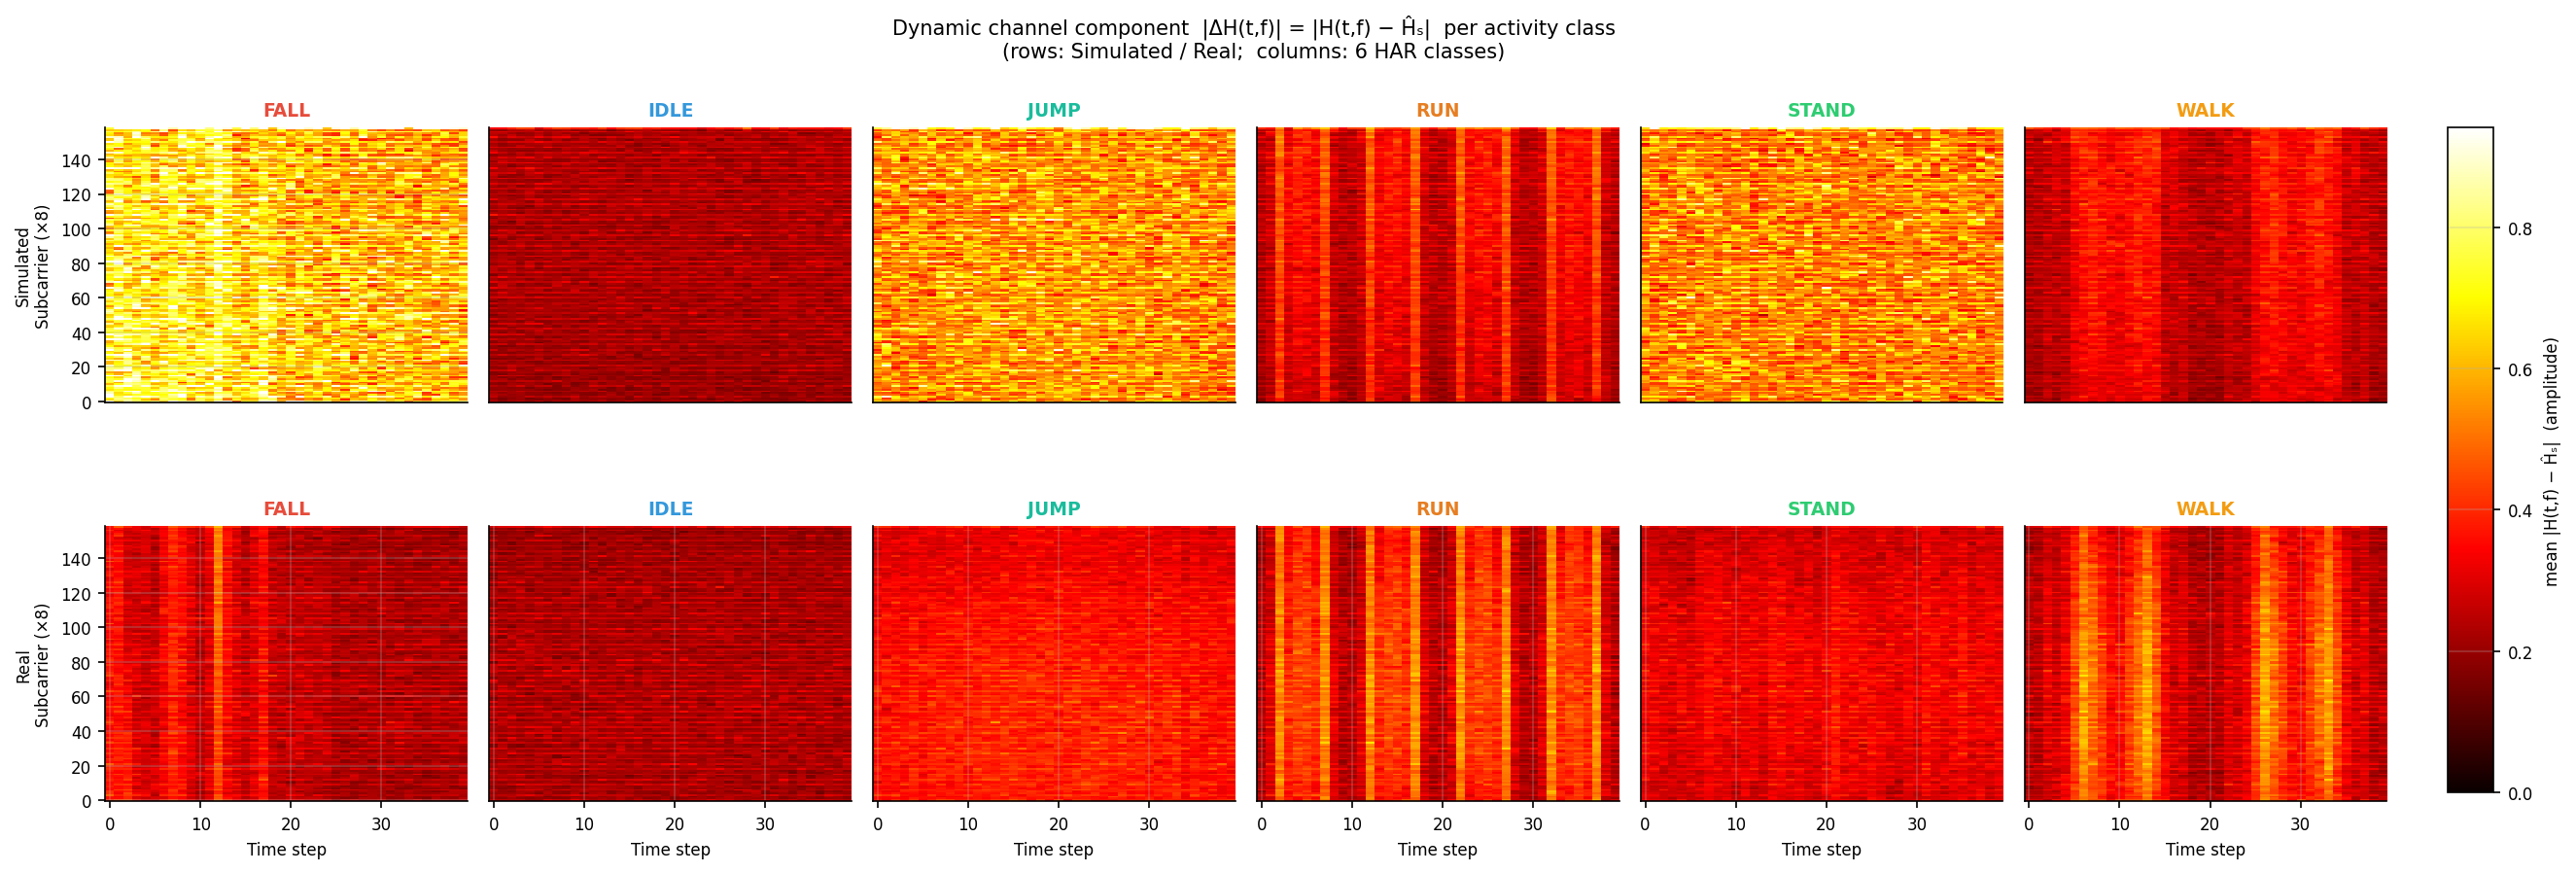

Saved → figs/dataset_v2/analysis_plots/09_delta_H_heatmap.{png,pdf}


In [7]:

# ── 2b. Dynamic component |ΔH(t,f)| per class ──────────────────────────────
# H_s estimated as mean amplitude across all IDLE samples and time steps

H_s_sim  = X_sim [y_sim  == 'IDLE', :, :, 2].mean(axis=(0, 1))  # (SC,)
H_s_real = X_real[y_real == 'IDLE', :, :, 2].mean(axis=(0, 1))  # (SC,)

SC_STRIDE = 8
NC        = len(CLASSES)

fig, axes = plt.subplots(2, NC, figsize=(3.5 * NC, 6),
                         constrained_layout=False)
fig.subplots_adjust(right=0.87, hspace=0.45, wspace=0.06)
cax = fig.add_axes([0.89, 0.12, 0.015, 0.76])

# first pass: collect maps + find shared vmax (97th-percentile across all)
maps   = {}
vmax_v = 0.0

for row, (X, y, H_s) in enumerate([
        (X_sim,  y_sim,  H_s_sim),
        (X_real, y_real, H_s_real)]):
    for col, cls in enumerate(CLASSES):
        mask = (y == cls)
        if not mask.any():
            maps[(row, col)] = None
            continue
        AMP  = X[mask, :, :, 2].astype(np.float32)           # (N, T, SC)
        dAMP = np.abs(AMP - H_s[None, None, :])               # |H(t,f) − Ĥs|
        hmap = dAMP.mean(axis=0)[:, ::SC_STRIDE].T            # (SC', T)
        maps[(row, col)] = hmap
        vmax_v = max(vmax_v, float(np.percentile(hmap, 97)))

# second pass: plot
im_ref = None
for row, domain in enumerate(['Simulated', 'Real']):
    for col, cls in enumerate(CLASSES):
        ax   = axes[row, col]
        hmap = maps[(row, col)]
        if hmap is None:
            ax.set_visible(False)
            continue
        im_ref = ax.imshow(hmap, aspect='auto', origin='lower',
                           cmap='hot', vmin=0, vmax=vmax_v,
                           interpolation='nearest')
        ax.set_title(cls, color=CLASS_COLORS.get(cls, 'k'),
                     fontweight='bold', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{domain}\nSubcarrier (×{SC_STRIDE})', fontsize=8)
        else:
            ax.set_yticks([])
        if row == 1:
            ax.set_xlabel('Time step', fontsize=8)
        else:
            ax.set_xticks([])

if im_ref is not None:
    cbar = fig.colorbar(im_ref, cax=cax)
    cbar.set_label('mean |H(t,f) − Ĥₛ|  (amplitude)', fontsize=8)

fig.suptitle(
    'Dynamic channel component  |ΔH(t,f)| = |H(t,f) − Ĥₛ|  per activity class\n'
    '(rows: Simulated / Real;  columns: 6 HAR classes)',
    fontsize=10, y=1.01)

save_fig(fig, '09_delta_H_heatmap')
plt.show()
plt.close()
print("Saved → figs/dataset_v2/analysis_plots/09_delta_H_heatmap.{png,pdf}")


In [8]:
F_sim  = np.hstack([F_static_sim,  F_doppler_sim])
F_real = np.hstack([F_static_real, F_doppler_real])

scaler  = StandardScaler()
Fs_sim  = scaler.fit_transform(F_sim)
Fs_real = scaler.transform(F_real)

print(f'Total features: {F_sim.shape[1]}  ({N_STATIC} static + {N_DOPPLER} Doppler)')
print(f'F_sim: {F_sim.shape}   F_real: {F_real.shape}')


Total features: 19  (7 static + 12 Doppler)
F_sim: (300, 19)   F_real: (300, 19)


## 3. Static feature distributions

Saved: 01_violin_static_sim_vs_real.png / .pdf


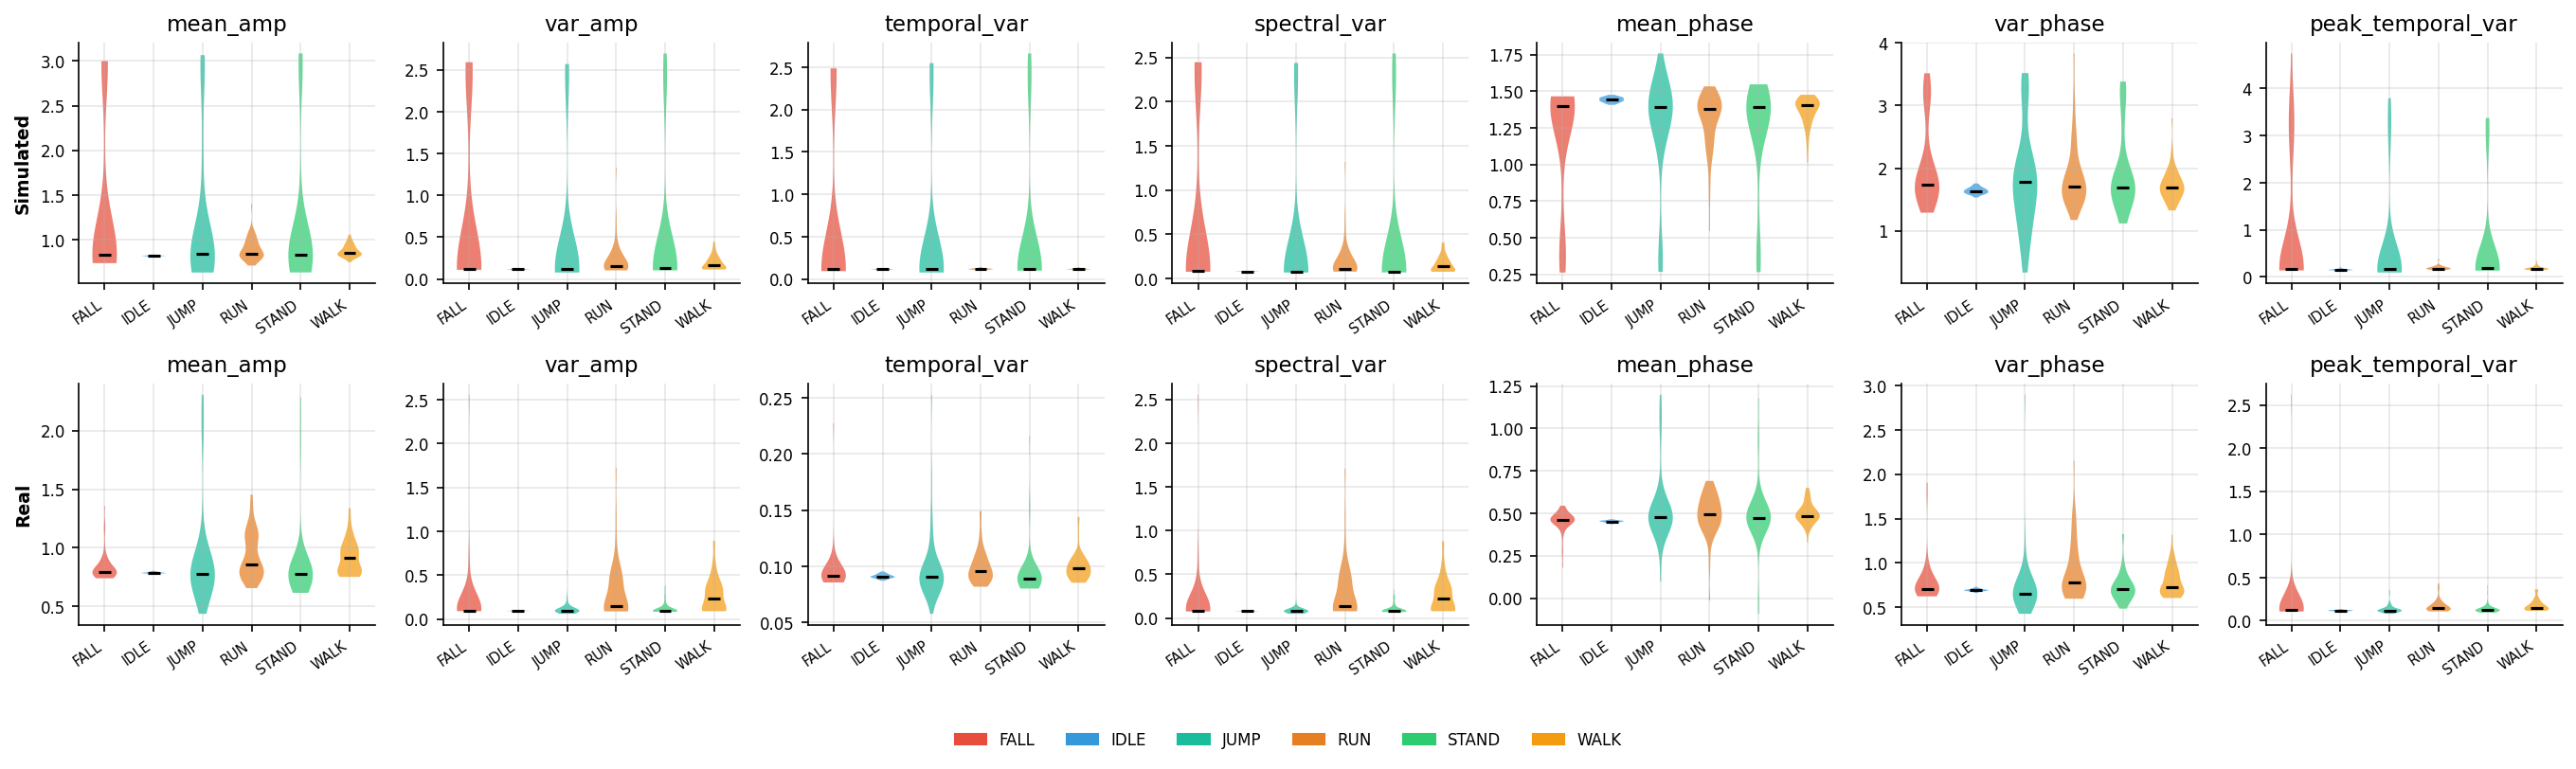

In [9]:
def violin_plot_features(F_sim_f, F_real_f, feat_names, stem, ncols=None):
    nf = len(feat_names)
    nc = ncols or nf
    fig, axes = plt.subplots(2, nc, figsize=(2.6 * nc, 5.2))
    for row, (F, y, domain) in enumerate([
        (F_sim_f,  y_sim,  'Simulated'),
        (F_real_f, y_real, 'Real'),
    ]):
        for col in range(nc):
            ax = axes[row, col]
            if col >= nf:
                ax.set_visible(False)
                continue
            valid     = [(i, c) for i, c in enumerate(CLASSES) if (y == c).any()]
            positions = [i for i, c in valid]
            valid_cls = [c for i, c in valid]
            data      = [F[y == c, col] for i, c in valid]
            parts = ax.violinplot(data, positions=positions,
                                  showmedians=True, showextrema=False)
            for pc, cls in zip(parts['bodies'], valid_cls):
                pc.set_facecolor(CLASS_COLORS[cls])
                pc.set_alpha(0.72)
            parts['cmedians'].set_color('black')
            ax.set_xticks(range(len(CLASSES)))
            ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=7)
            ax.set_title(feat_names[col])
            if col == 0:
                ax.set_ylabel(domain, fontweight='bold')
    handles = [mpatches.Patch(color=CLASS_COLORS[c], label=c) for c in CLASSES]
    fig.legend(handles=handles, loc='lower center', ncol=len(CLASSES),
               bbox_to_anchor=(0.5, -0.04), frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    save_fig(fig, stem)
    plt.show()
    plt.close()

violin_plot_features(F_static_sim, F_static_real, STATIC_FEAT_NAMES,
                     '01_violin_static_sim_vs_real')


## 4. Doppler feature distributions

Saved: 02_violin_doppler_sim_vs_real.png / .pdf


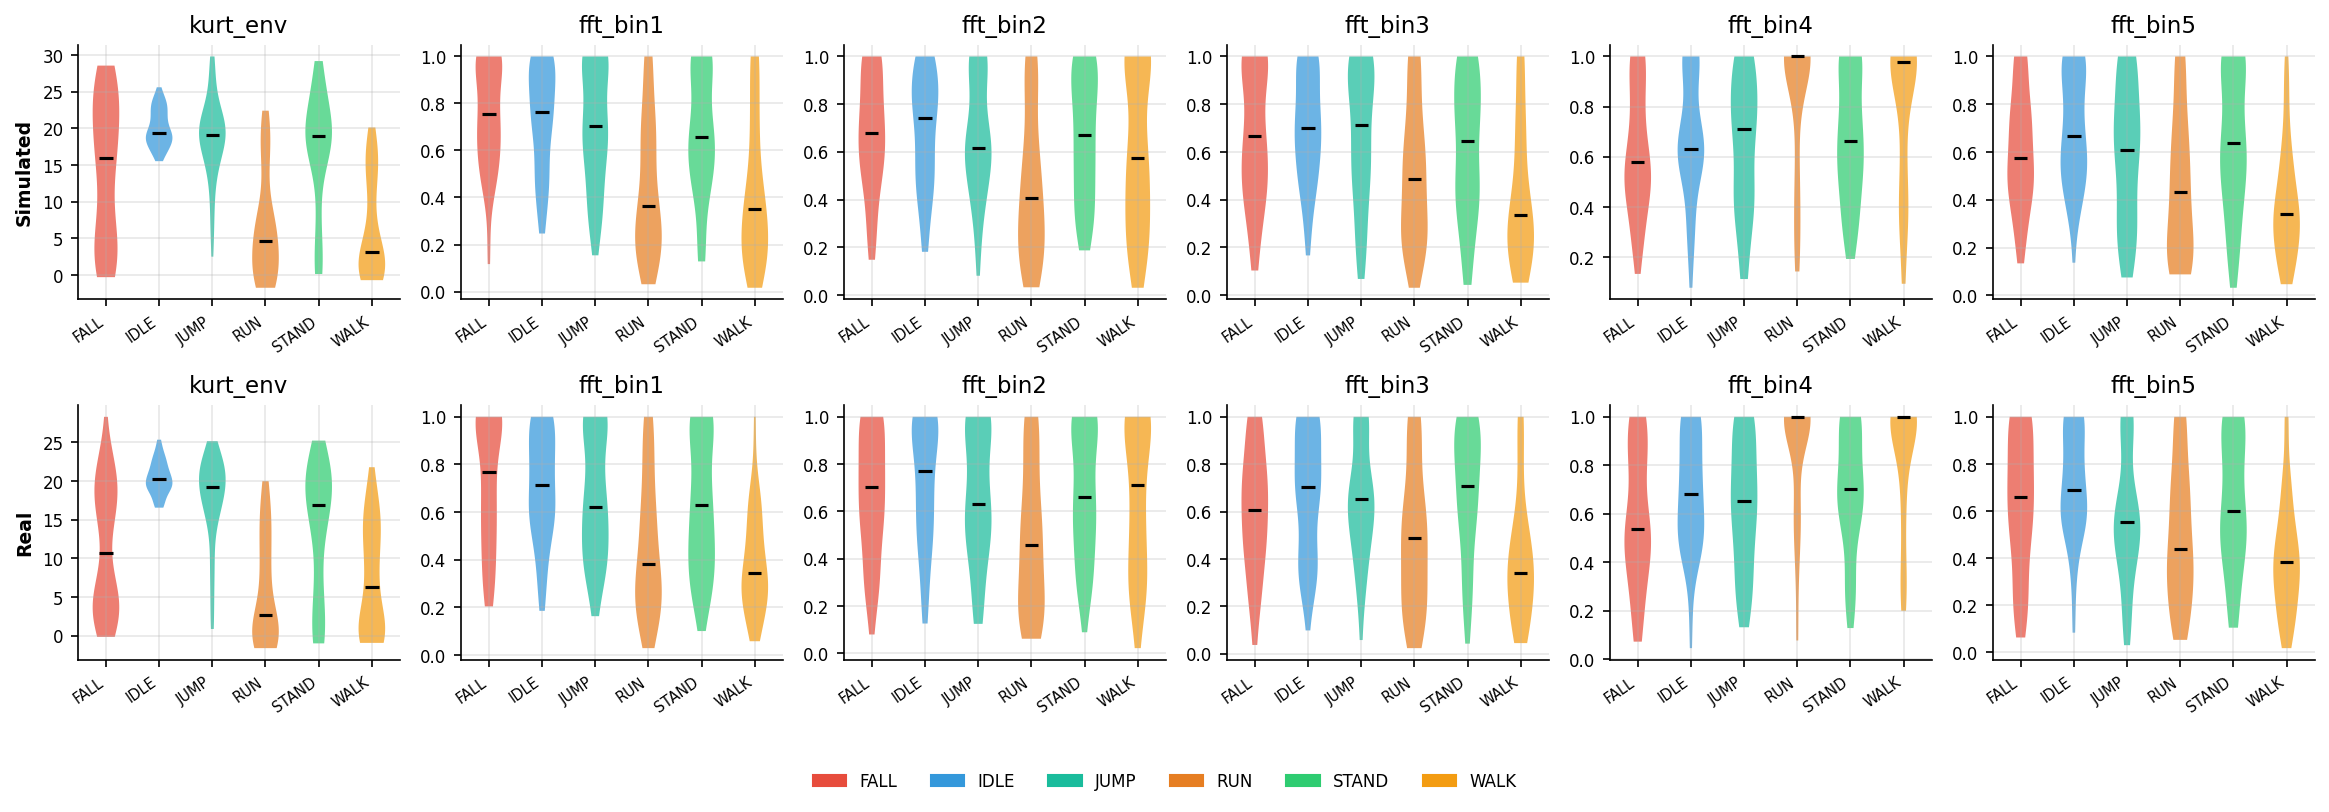

In [10]:
violin_plot_features(F_doppler_sim, F_doppler_real, DOPPLER_FEAT_NAMES,
                     '02_violin_doppler_sim_vs_real', ncols=6)


## 5. Doppler heatmap (time x subcarrier)

Saved: 03_doppler_heatmap.png / .pdf


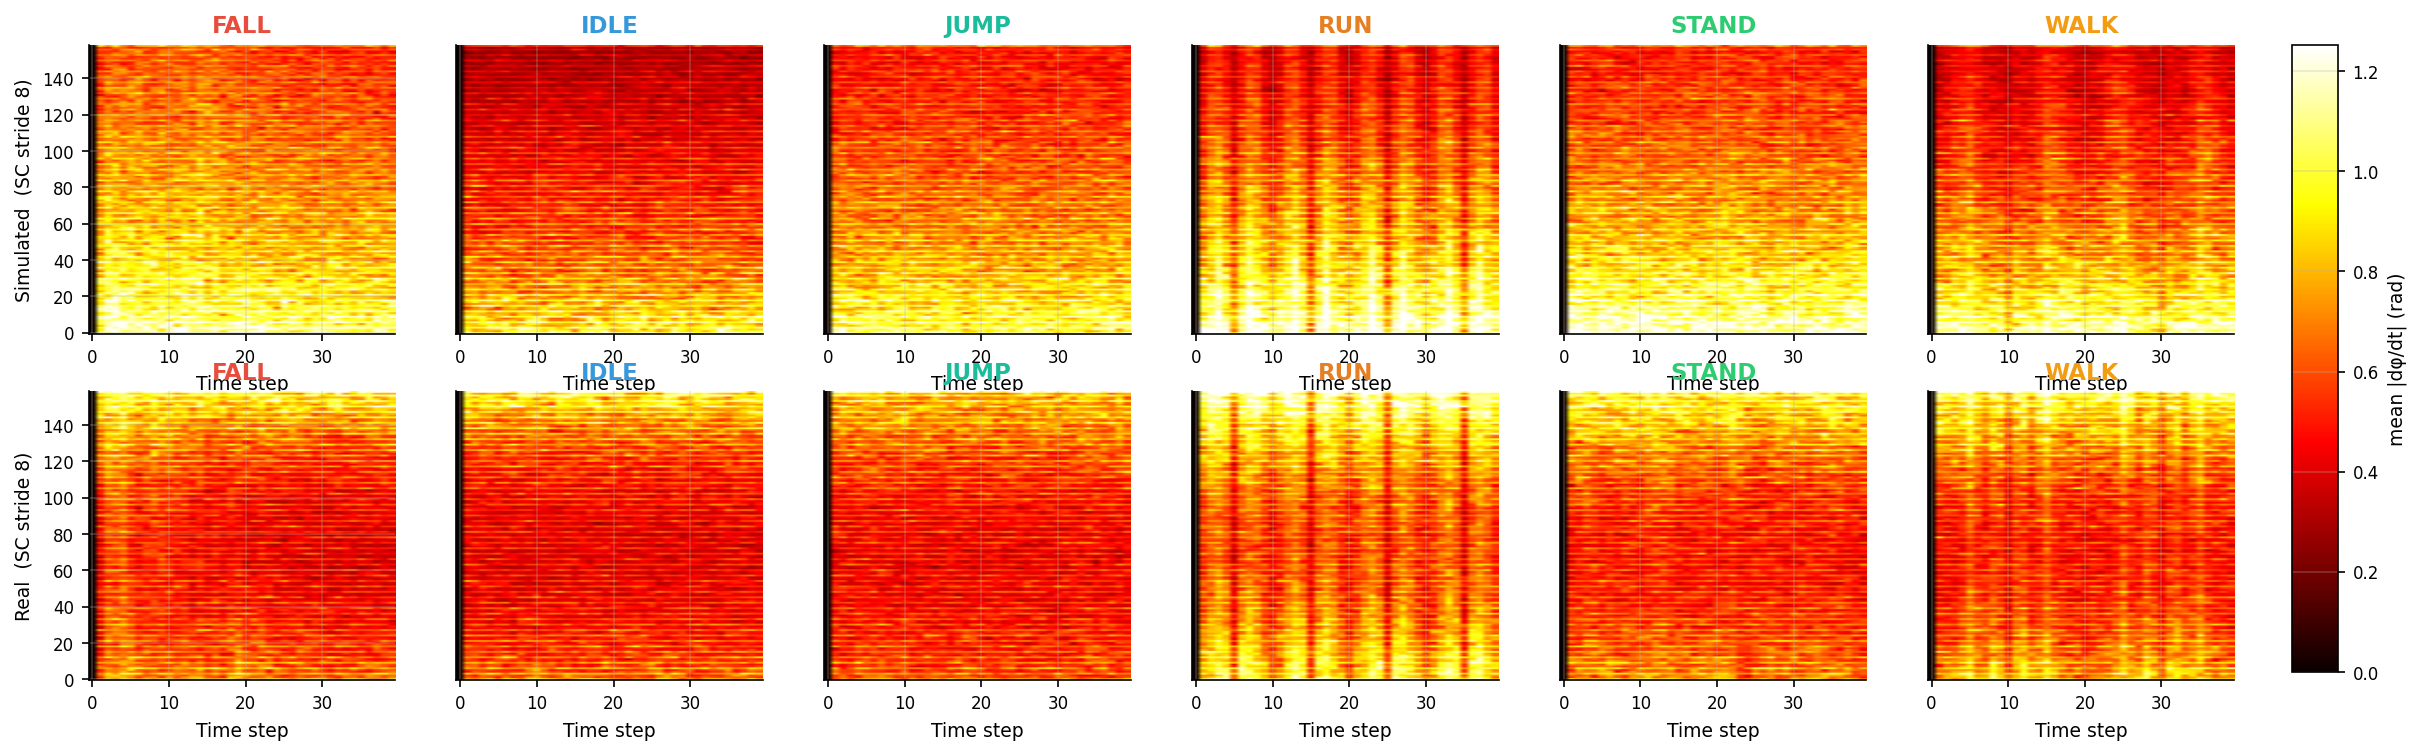

In [11]:
SC_STRIDE = 8
NC = len(CLASSES)
fig, axes = plt.subplots(2, NC, figsize=(3.2 * NC, 5.5))
fig.subplots_adjust(right=0.87)
cax = fig.add_axes([0.89, 0.12, 0.016, 0.76])

vmax_val = None
maps = {}
for row, (dPHA, y) in enumerate([(abs_dPHA_sim, y_sim), (abs_dPHA_real, y_real)]):
    for col, cls in enumerate(CLASSES):
        mask = y == cls
        if not mask.any():
            maps[(row, col)] = None
            continue
        hmap = dPHA[mask].mean(axis=0)[:, ::SC_STRIDE].T
        maps[(row, col)] = hmap
        v97 = np.percentile(hmap, 97)
        vmax_val = v97 if vmax_val is None else max(vmax_val, v97)

im_last = None
for row, domain in enumerate(['Simulated', 'Real']):
    for col, cls in enumerate(CLASSES):
        ax = axes[row, col]
        hmap = maps[(row, col)]
        if hmap is None:
            ax.set_visible(False)
            continue
        im_last = ax.imshow(hmap, aspect='auto', origin='lower',
                            cmap='hot', vmin=0, vmax=vmax_val)
        ax.set_title(cls, color=CLASS_COLORS[cls], fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{domain}  (SC stride {SC_STRIDE})')
        else:
            ax.set_yticks([])
        ax.set_xlabel('Time step')

if im_last is not None:
    cbar = fig.colorbar(im_last, cax=cax)
    cbar.set_label('mean |dφ/dt| (rad)')

save_fig(fig, '03_doppler_heatmap')
plt.show()
plt.close()


## 6. Temporal profiles of rel_env_t

Saved: 04_rel_env_t_profiles.png / .pdf


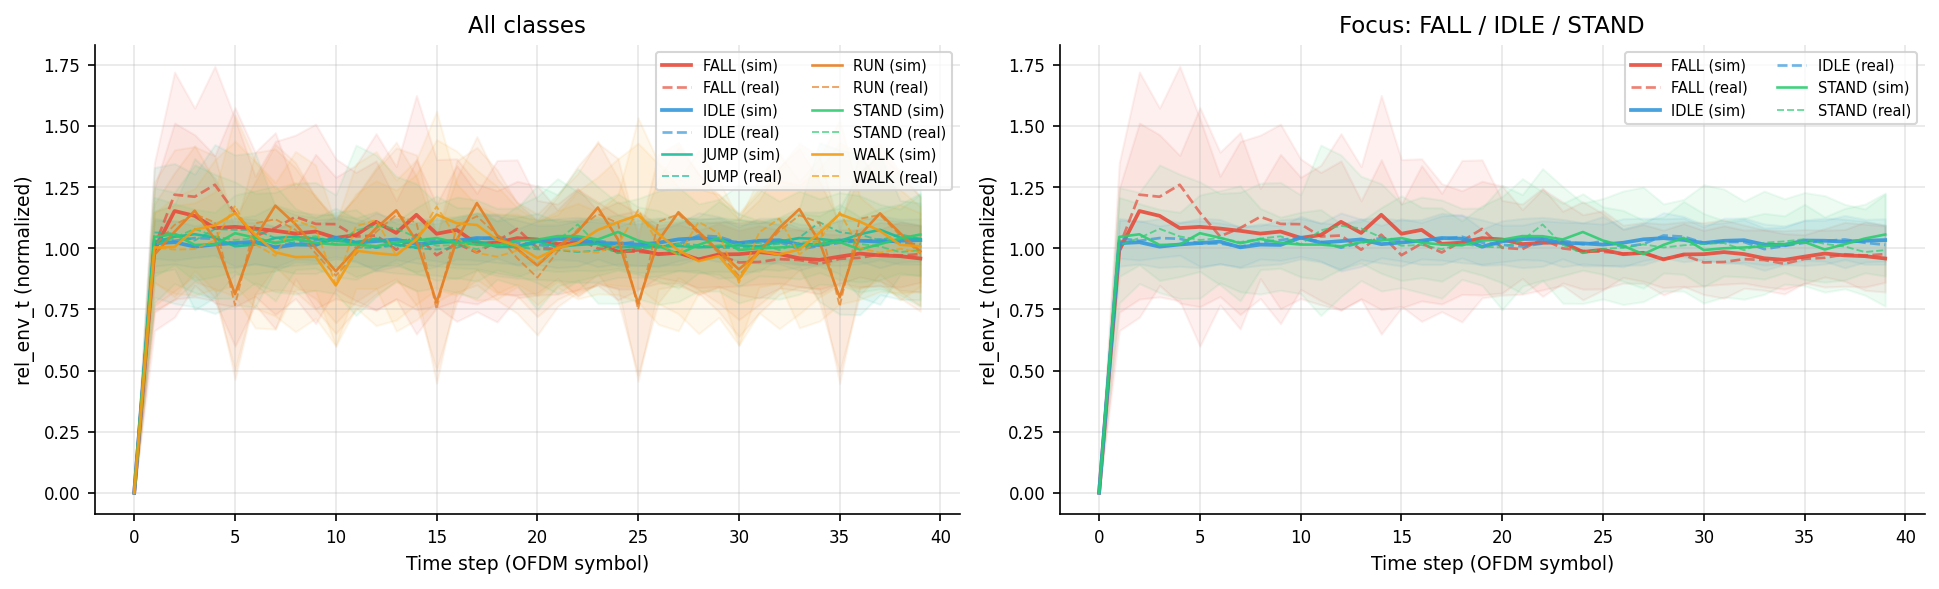

In [12]:
t_ax = np.arange(rel_env_sim.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

focus_sets = [CLASSES, ['FALL', 'IDLE', 'STAND']]
subtitles  = ['All classes', 'Focus: FALL / IDLE / STAND']

for ax, focus, subtitle in zip(axes, focus_sets, subtitles):
    for cls in focus:
        for rel_env, y, ls, alpha, lw_base in [
            (rel_env_sim,  y_sim,  '-',  0.9, 1.8),
            (rel_env_real, y_real, '--', 0.7, 1.3),
        ]:
            mask = y == cls
            if not mask.any():
                continue
            mu    = rel_env[mask].mean(axis=0)
            sigma = rel_env[mask].std(axis=0)
            lw  = lw_base if cls in ('FALL', 'IDLE') else lw_base * 0.7
            dom = 'sim' if ls == '-' else 'real'
            ax.plot(t_ax, mu, color=CLASS_COLORS[cls], linestyle=ls,
                    alpha=alpha, linewidth=lw, label=f'{cls} ({dom})')
            ax.fill_between(t_ax, mu - sigma, mu + sigma,
                            color=CLASS_COLORS[cls], alpha=0.08)
    ax.set_xlabel('Time step (OFDM symbol)')
    ax.set_ylabel('rel_env_t (normalized)')
    ax.set_title(subtitle)
    ax.legend(ncol=2, fontsize=7, loc='upper right')

plt.tight_layout()
save_fig(fig, '04_rel_env_t_profiles')
plt.show()
plt.close()


## 7. PCA 2D — simulated vs real

Saved: 05_pca_sim_vs_real.png / .pdf


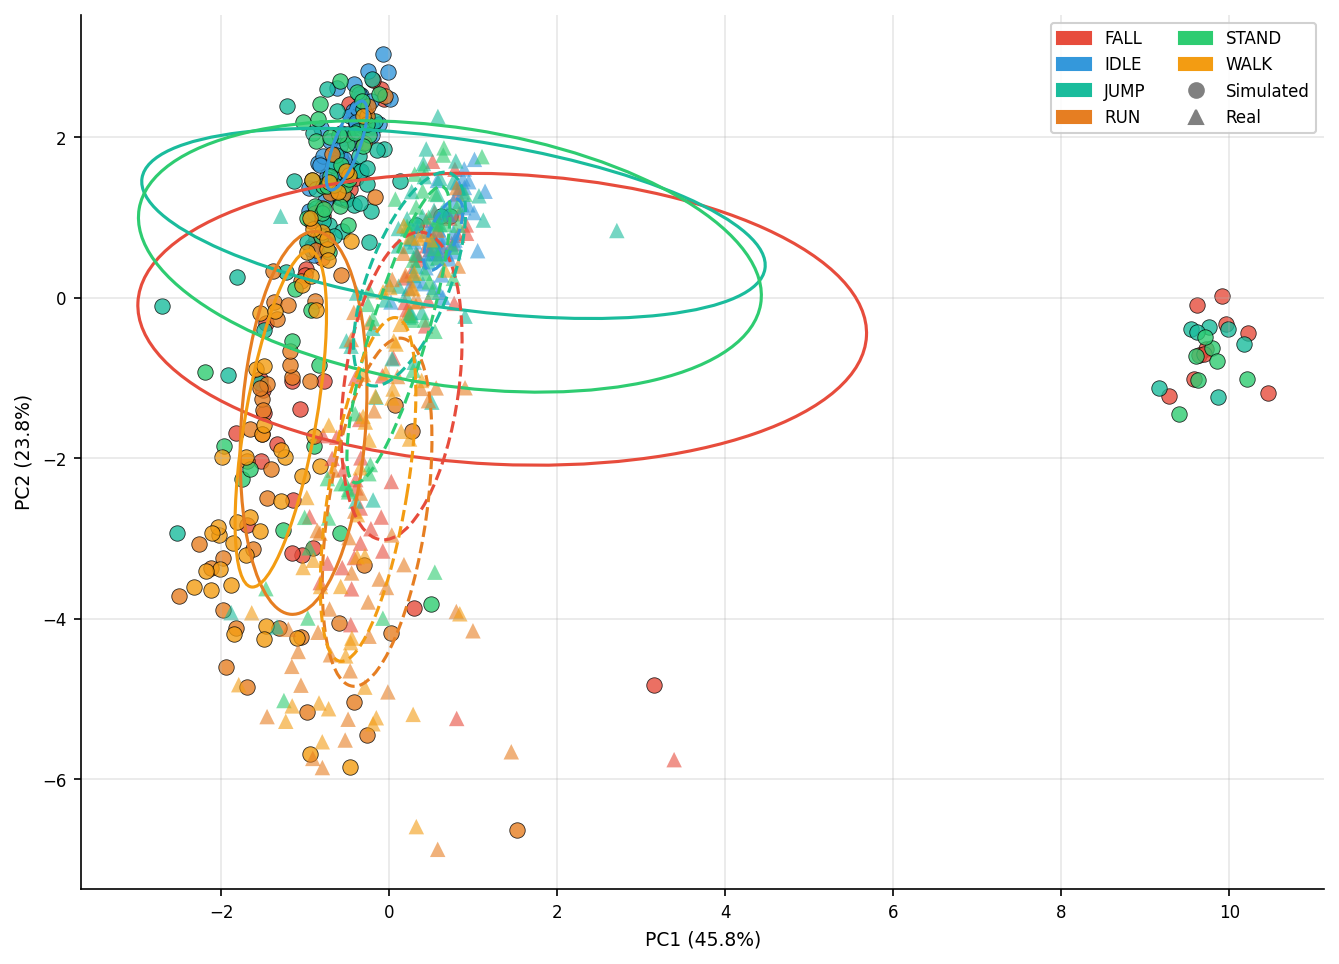

In [13]:
def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order  = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle  = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(np.abs(eigvals[0]))
    height = 2 * n_std * np.sqrt(np.abs(eigvals[1]))
    ell = Ellipse(xy=(np.mean(x), np.mean(y)),
                  width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

pca    = PCA(n_components=2)
P_sim  = pca.fit_transform(Fs_sim)
P_real = pca.transform(Fs_real)

fig, ax = plt.subplots(figsize=(9, 6.5))
markers = {'sim': 'o', 'real': '^'}

for domain, P, y in [('sim', P_sim, y_sim), ('real', P_real, y_real)]:
    for cls in CLASSES:
        mask = y == cls
        if not mask.any():
            continue
        ax.scatter(P[mask, 0], P[mask, 1],
                   c=CLASS_COLORS[cls], marker=markers[domain],
                   s=55, alpha=0.8 if domain == 'sim' else 0.6,
                   edgecolors='k' if domain == 'sim' else 'none',
                   linewidths=0.4)
        confidence_ellipse(P[mask, 0], P[mask, 1], ax, n_std=1.0,
                           edgecolor=CLASS_COLORS[cls], facecolor='none',
                           linewidth=1.5,
                           linestyle='-' if domain == 'sim' else '--',
                           zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

class_h = [mpatches.Patch(color=CLASS_COLORS[c], label=c) for c in CLASSES]
dom_h   = [
    plt.Line2D([0], [0], marker='o', color='gray', linestyle='', label='Simulated', markersize=7),
    plt.Line2D([0], [0], marker='^', color='gray', linestyle='', label='Real',      markersize=7),
]
ax.legend(handles=class_h + dom_h, fontsize=8, ncol=2,
          loc='upper right', framealpha=0.9)
plt.tight_layout()
save_fig(fig, '05_pca_sim_vs_real')
plt.show()
plt.close()


## 8. FDR: separability and transferability

Saved: 06_fdr_heatmap.png / .pdf


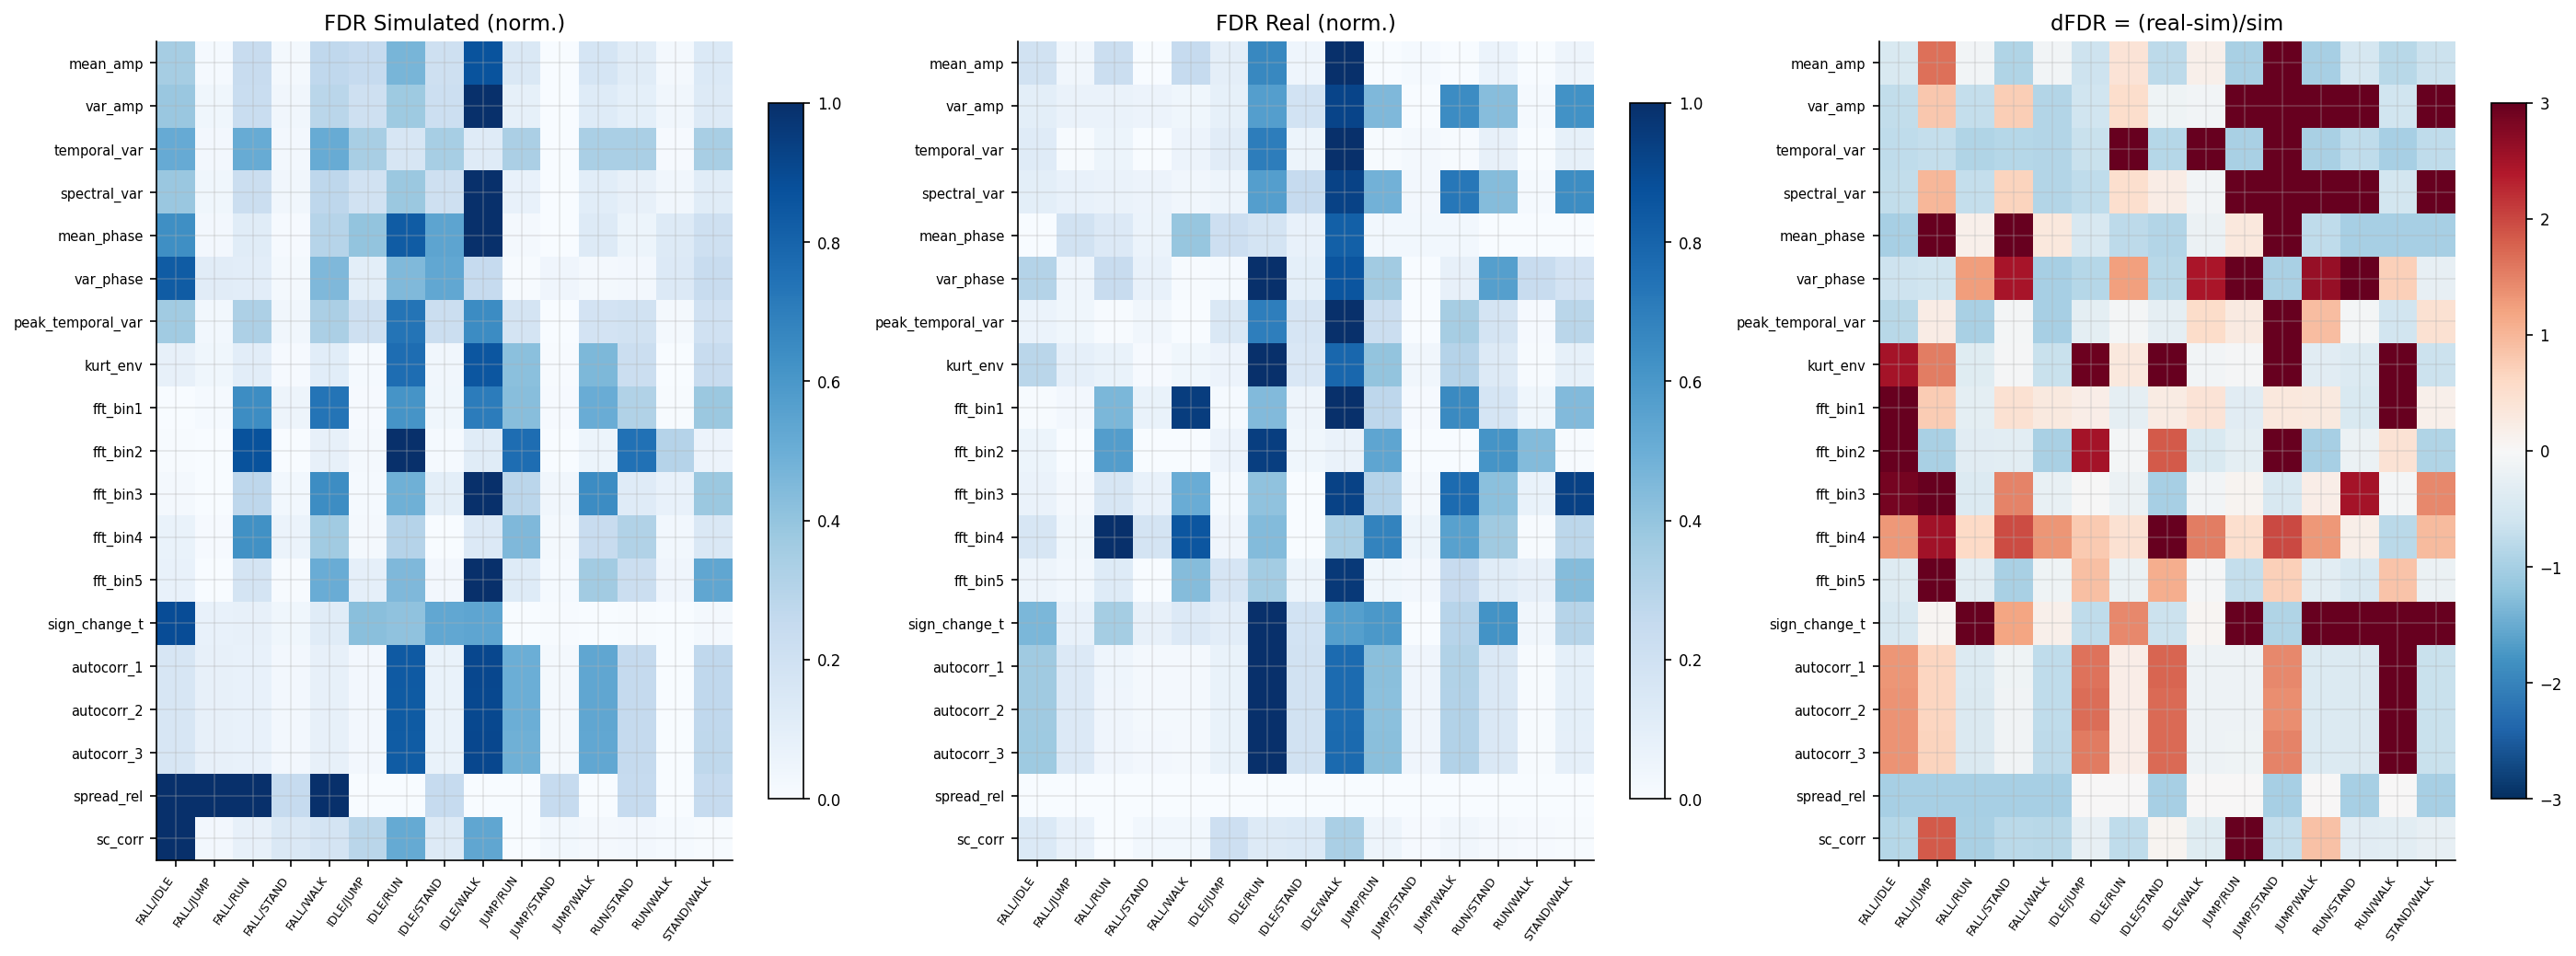

In [14]:
class_pairs = list(itertools.combinations(CLASSES, 2))
pair_labels = [f'{c1}/{c2}' for c1, c2 in class_pairs]

def compute_fdr(F, y, pairs):
    fdr = np.zeros((N_FEATS, len(pairs)))
    for fi in range(N_FEATS):
        for pi, (c1, c2) in enumerate(pairs):
            d1 = F[y == c1, fi] if (y == c1).any() else np.array([0.])
            d2 = F[y == c2, fi] if (y == c2).any() else np.array([0.])
            num = (d1.mean() - d2.mean()) ** 2
            den = d1.var() + d2.var() + 1e-9
            fdr[fi, pi] = num / den
    return fdr

fdr_sim  = compute_fdr(F_sim,  y_sim,  class_pairs)
fdr_real = compute_fdr(F_real, y_real, class_pairs)
fdr_max  = np.maximum(fdr_sim, fdr_real).max(axis=1, keepdims=True) + 1e-9
fdr_s_n  = fdr_sim  / fdr_max
fdr_r_n  = fdr_real / fdr_max
delta    = (fdr_real - fdr_sim) / (fdr_sim + 1e-9)
delta    = np.clip(delta, -3, 3)

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
panels = [
    (fdr_s_n, 'FDR Simulated (norm.)', 'Blues',  0,  1),
    (fdr_r_n, 'FDR Real (norm.)',      'Blues',  0,  1),
    (delta,   'dFDR = (real-sim)/sim', 'RdBu_r', -3, 3),
]
for ax, (mat, title, cmap, vmin, vmax) in zip(axes, panels):
    im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pair_labels)))
    ax.set_xticklabels(pair_labels, rotation=55, ha='right', fontsize=6)
    ax.set_yticks(range(N_FEATS))
    ax.set_yticklabels(ALL_FEAT_NAMES, fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
save_fig(fig, '06_fdr_heatmap')
plt.show()
plt.close()


## 9. Domain gap per feature and class

Saved: 07_domain_gap_distance.png / .pdf


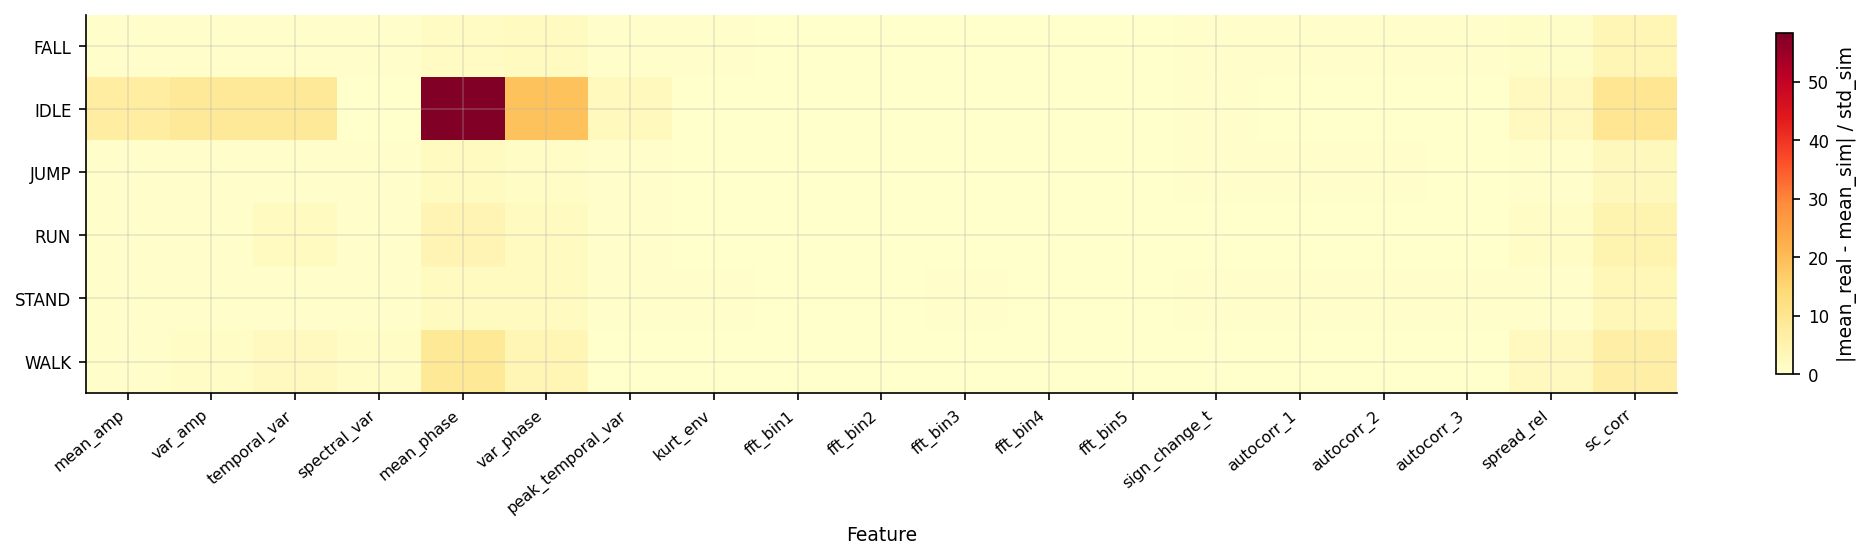

In [15]:
gap = np.zeros((len(CLASSES), N_FEATS))
for ci, cls in enumerate(CLASSES):
    ms = y_sim  == cls
    mr = y_real == cls
    if not ms.any() or not mr.any():
        continue
    mu_s = F_sim[ms].mean(axis=0)
    sd_s = F_sim[ms].std(axis=0) + 1e-9
    mu_r = F_real[mr].mean(axis=0)
    gap[ci] = np.abs(mu_r - mu_s) / sd_s

fig, ax = plt.subplots(figsize=(14, 3.8))
im = ax.imshow(gap, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(N_FEATS))
ax.set_xticklabels(ALL_FEAT_NAMES, rotation=40, ha='right', fontsize=7.5)
ax.set_yticks(range(len(CLASSES)))
ax.set_yticklabels(CLASSES)
ax.set_xlabel('Feature')
cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label('|mean_real - mean_sim| / std_sim')
plt.tight_layout()
save_fig(fig, '07_domain_gap_distance')
plt.show()
plt.close()


## 10. FALL vs IDLE focus

Saved: 08_fall_idle_focus.png / .pdf


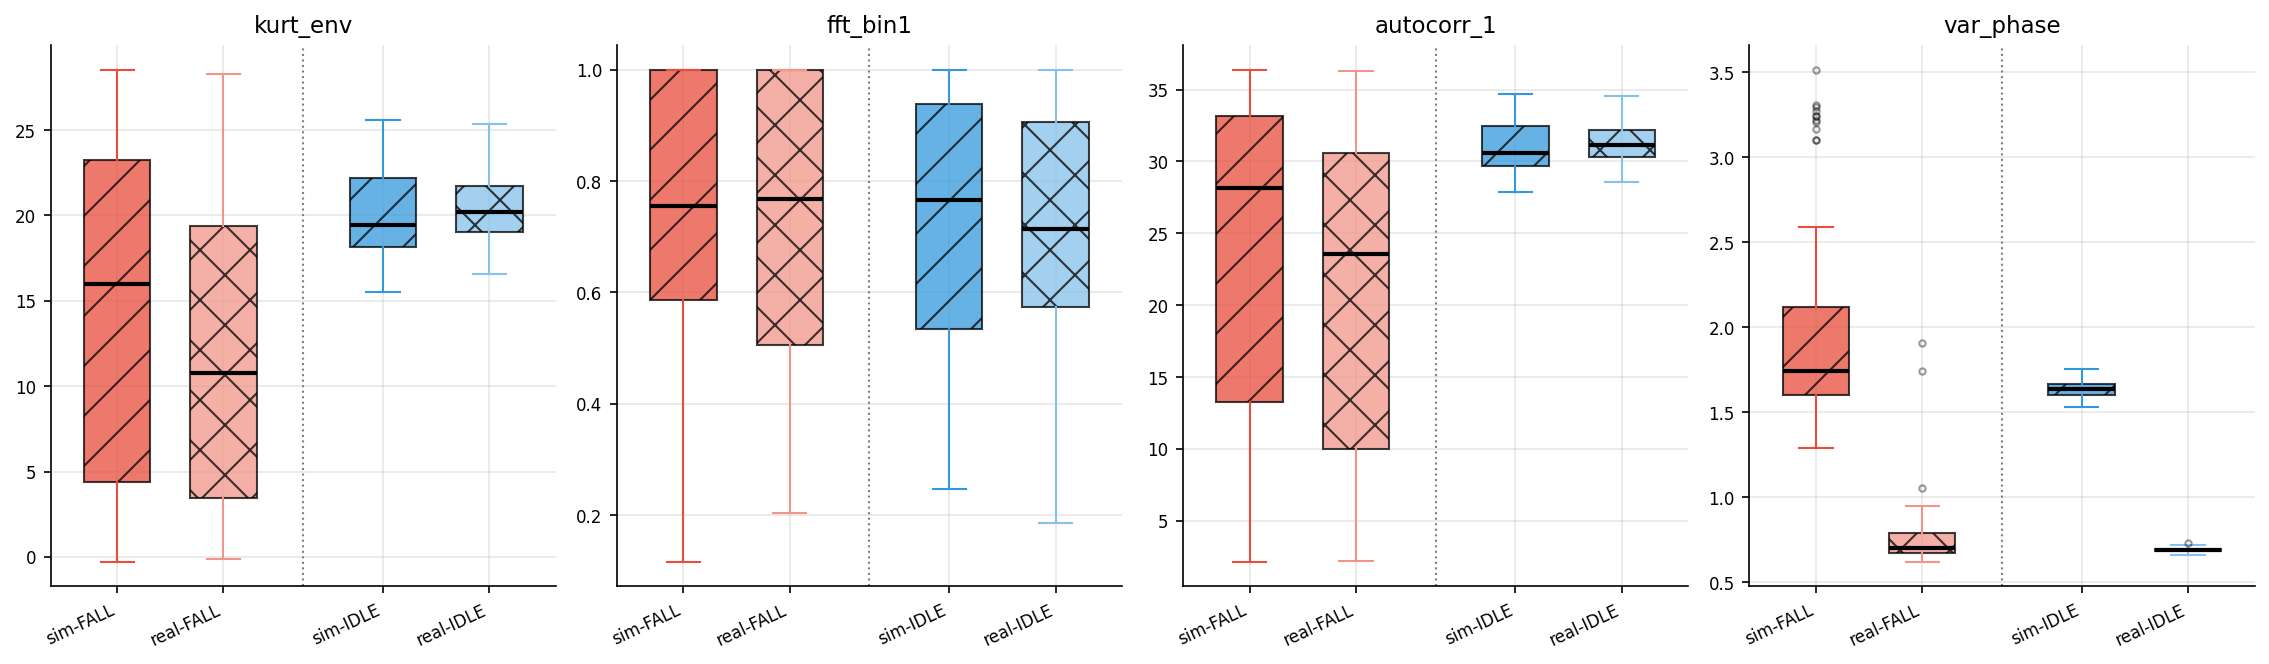

In [16]:
focus_groups = [
    ('sim-FALL',  F_sim[y_sim   == 'FALL'],  '#e74c3c', '/'),
    ('real-FALL', F_real[y_real == 'FALL'],  '#f1948a', 'x'),
    ('sim-IDLE',  F_sim[y_sim   == 'IDLE'],  '#3498db', '/'),
    ('real-IDLE', F_real[y_real == 'IDLE'],  '#85c1e9', 'x'),
]

focus_features = {
    'kurt_env':   N_STATIC + 0,
    'fft_bin1':   N_STATIC + 1,
    'autocorr_1': N_STATIC + 7,
    'var_phase':  5,
}

positions = [1.0, 1.8, 3.0, 3.8]
fig, axes = plt.subplots(1, len(focus_features), figsize=(3.8 * len(focus_features), 4.5))

for ax, (fname, fidx) in zip(axes, focus_features.items()):
    for pos, (name, data, color, hatch) in zip(positions, focus_groups):
        ax.boxplot(
            data[:, fidx],
            positions=[pos], widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.75, hatch=hatch),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            flierprops=dict(marker='o', markersize=3, alpha=0.4, color=color),
        )
    ax.set_xticks(positions)
    ax.set_xticklabels([g[0] for g in focus_groups], rotation=25, ha='right', fontsize=8)
    ax.set_title(fname)
    ax.axvline(x=2.4, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig(fig, '08_fall_idle_focus')
plt.show()
plt.close()


## Summary of generated figures

| File (PNG + PDF) | Content | Paper |
|---|---|---|
| `01_violin_static_sim_vs_real` | Distributions of 7 static features (sim vs real) | — |
| `02_violin_doppler_sim_vs_real` | Distributions of 12 Doppler scalar features | — |
| `03_doppler_heatmap` | Mean \|dphi/dt\| heatmap per class (time x subcarrier) | — |
| `04_rel_env_t_profiles` | Temporal profiles of rel_env_t per class | — |
| `05_pca_sim_vs_real` | PCA 2D: separability and domain shift | Fig.15 |
| `06_fdr_heatmap` | FDR separability per feature x class pair (sim / real / delta) | — |
| `07_domain_gap_distance` | Domain gap: cluster distance real vs sim per feature and class | — |
| `08_fall_idle_focus` | FALL vs IDLE focus: 4 key features (sim/real comparison) | — |
| `09_delta_H_heatmap` | Dynamic component \|ΔH(t,f)\| per class (§2b) | Fig.3 |
| `10_temporal_var_profile` | Temporal profile Var_SC(AMP)(t) per class (§11) | Fig.14 |
| `12_fdr_per_feature` | FDR mean per feature, sim vs real — bar chart (§12) | **Fig.11** |

## 12. FDR mean per feature — bar chart  →  paper Fig.11

**Fisher Discriminant Ratio** medio per feature su tutte le 15 coppie di classi.

Sostituisce la figura `fdr_separability_sim_vs_real.png` (heatmap features × coppie, vecchio notebook `old_nb/doppler_analysis.ipynb`).

- **Asse y:** 19 feature (7 static + 12 Doppler scalars) ordinate per FDR sim decrescente  
- **Barre blu:** FDR simulato; **barre arancio:** FDR reale  
- **Messaggio chiave:** le feature Doppler (kurt_env, fft_bin*, autocorr) mantengono alta separabilità anche sul dataset reale

Output: `figs/dataset_v2/analysis_plots/12_fdr_per_feature.{png,pdf}`  
Paper ref: §6.1 — Fig. 11 (`figures/results/12_fdr_per_feature.pdf`)

Saved: 12_fdr_per_feature.png / .pdf


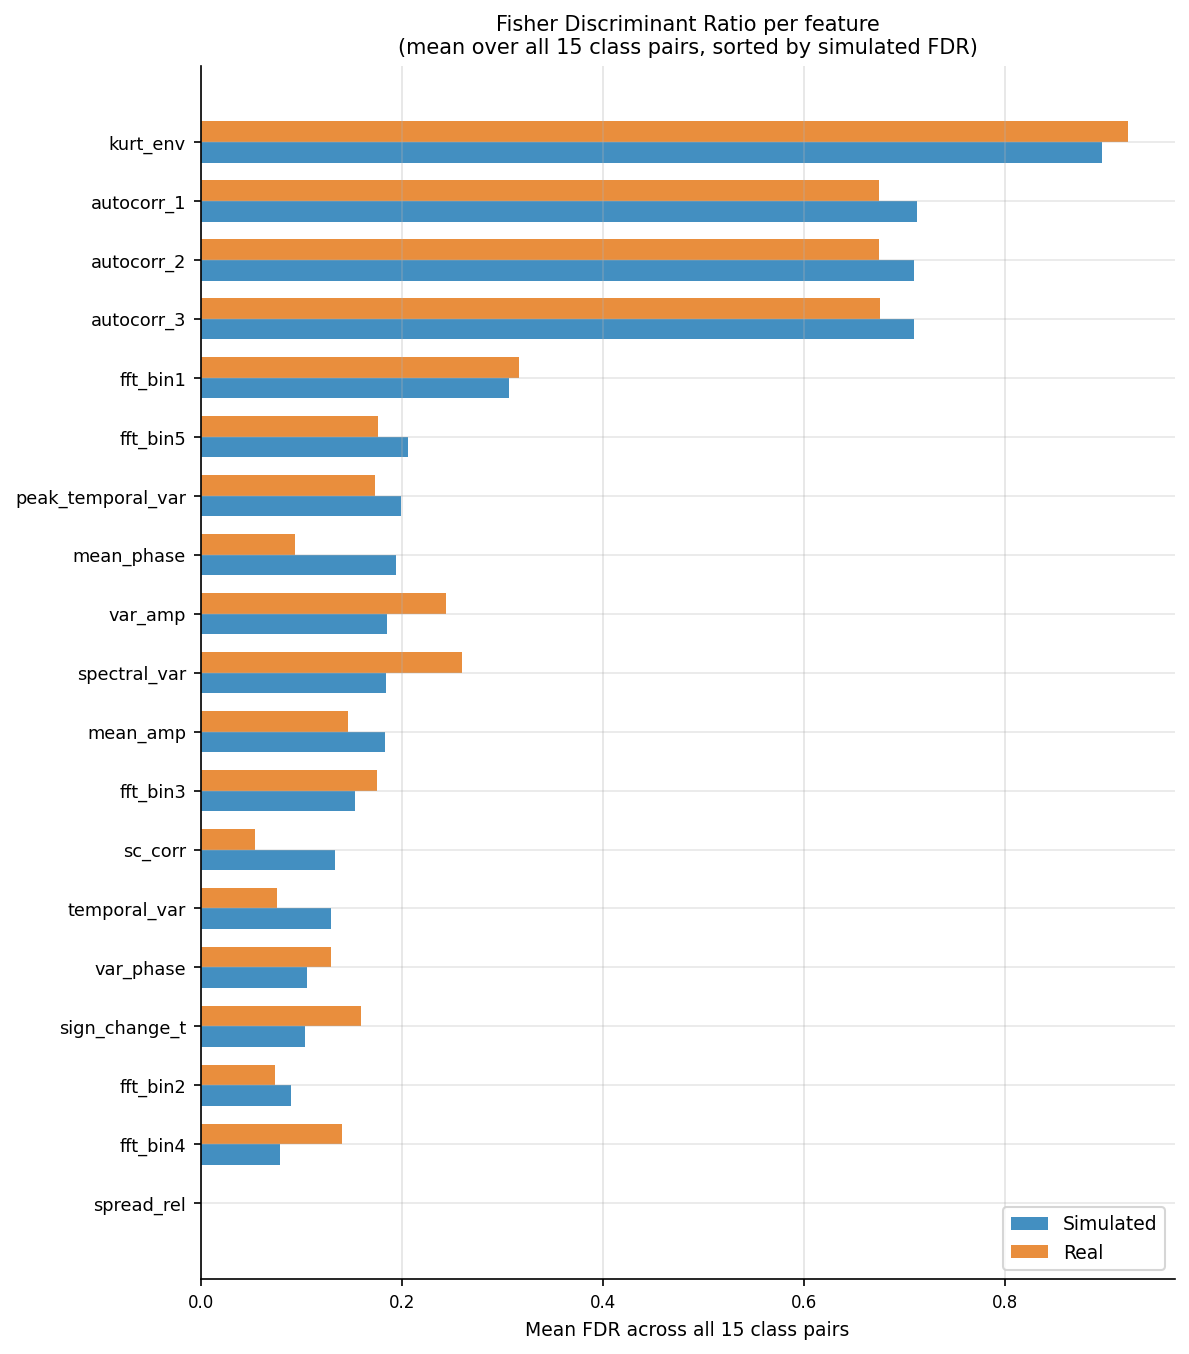

Saved → 12_fdr_per_feature.{png,pdf}  (→ paper Fig.11)


In [17]:

# ── 12. FDR mean per feature — bar chart (sim vs real) ── paper Fig.11 ───────
# Fonte: notebook csi_feature_analysis_sim_vs_real.ipynb  §12
# Usa fdr_sim / fdr_real (N_FEATS x N_PAIRS) già calcolati in §8 (cell-fig06)
# Output: figs/dataset_v2/analysis_plots/12_fdr_per_feature.{png,pdf}

fdr_sim_mean  = fdr_sim.mean(axis=1)   # media su tutte le 15 coppie di classi
fdr_real_mean = fdr_real.mean(axis=1)

# Ordina per FDR sim decrescente
order        = np.argsort(fdr_sim_mean)[::-1]
sorted_names = [ALL_FEAT_NAMES[i] for i in order]
sorted_sim   = fdr_sim_mean[order]
sorted_real  = fdr_real_mean[order]

NF    = len(sorted_names)
y_pos = np.arange(NF)
bar_h = 0.35

fig, ax = plt.subplots(figsize=(8, NF * 0.40 + 1.5))

ax.barh(y_pos + bar_h / 2, sorted_sim,  height=bar_h,
        color='#2980b9', alpha=0.88, label='Simulated')
ax.barh(y_pos - bar_h / 2, sorted_real, height=bar_h,
        color='#e67e22', alpha=0.88, label='Real')

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names, fontsize=8.5)
ax.set_xlabel('Mean FDR across all 15 class pairs', fontsize=9)
ax.set_title(
    'Fisher Discriminant Ratio per feature\n'
    '(mean over all 15 class pairs, sorted by simulated FDR)',
    fontsize=10)
ax.legend(fontsize=9, loc='lower right')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig(fig, '12_fdr_per_feature')
plt.show()
plt.close()
print("Saved → 12_fdr_per_feature.{png,pdf}  (→ paper Fig.11)")


## 11. Temporal variance profile per class  →  paper Fig.14

`Var_SC(AMP)(t)` = varianza dell'ampiezza sulle subcarrier ad ogni time step.
Sostituisce la versione da `old_nb/analyze_domain_gap.ipynb` (dpi=150, dataset_raw).

Saved: 10_temporal_var_profile.png / .pdf


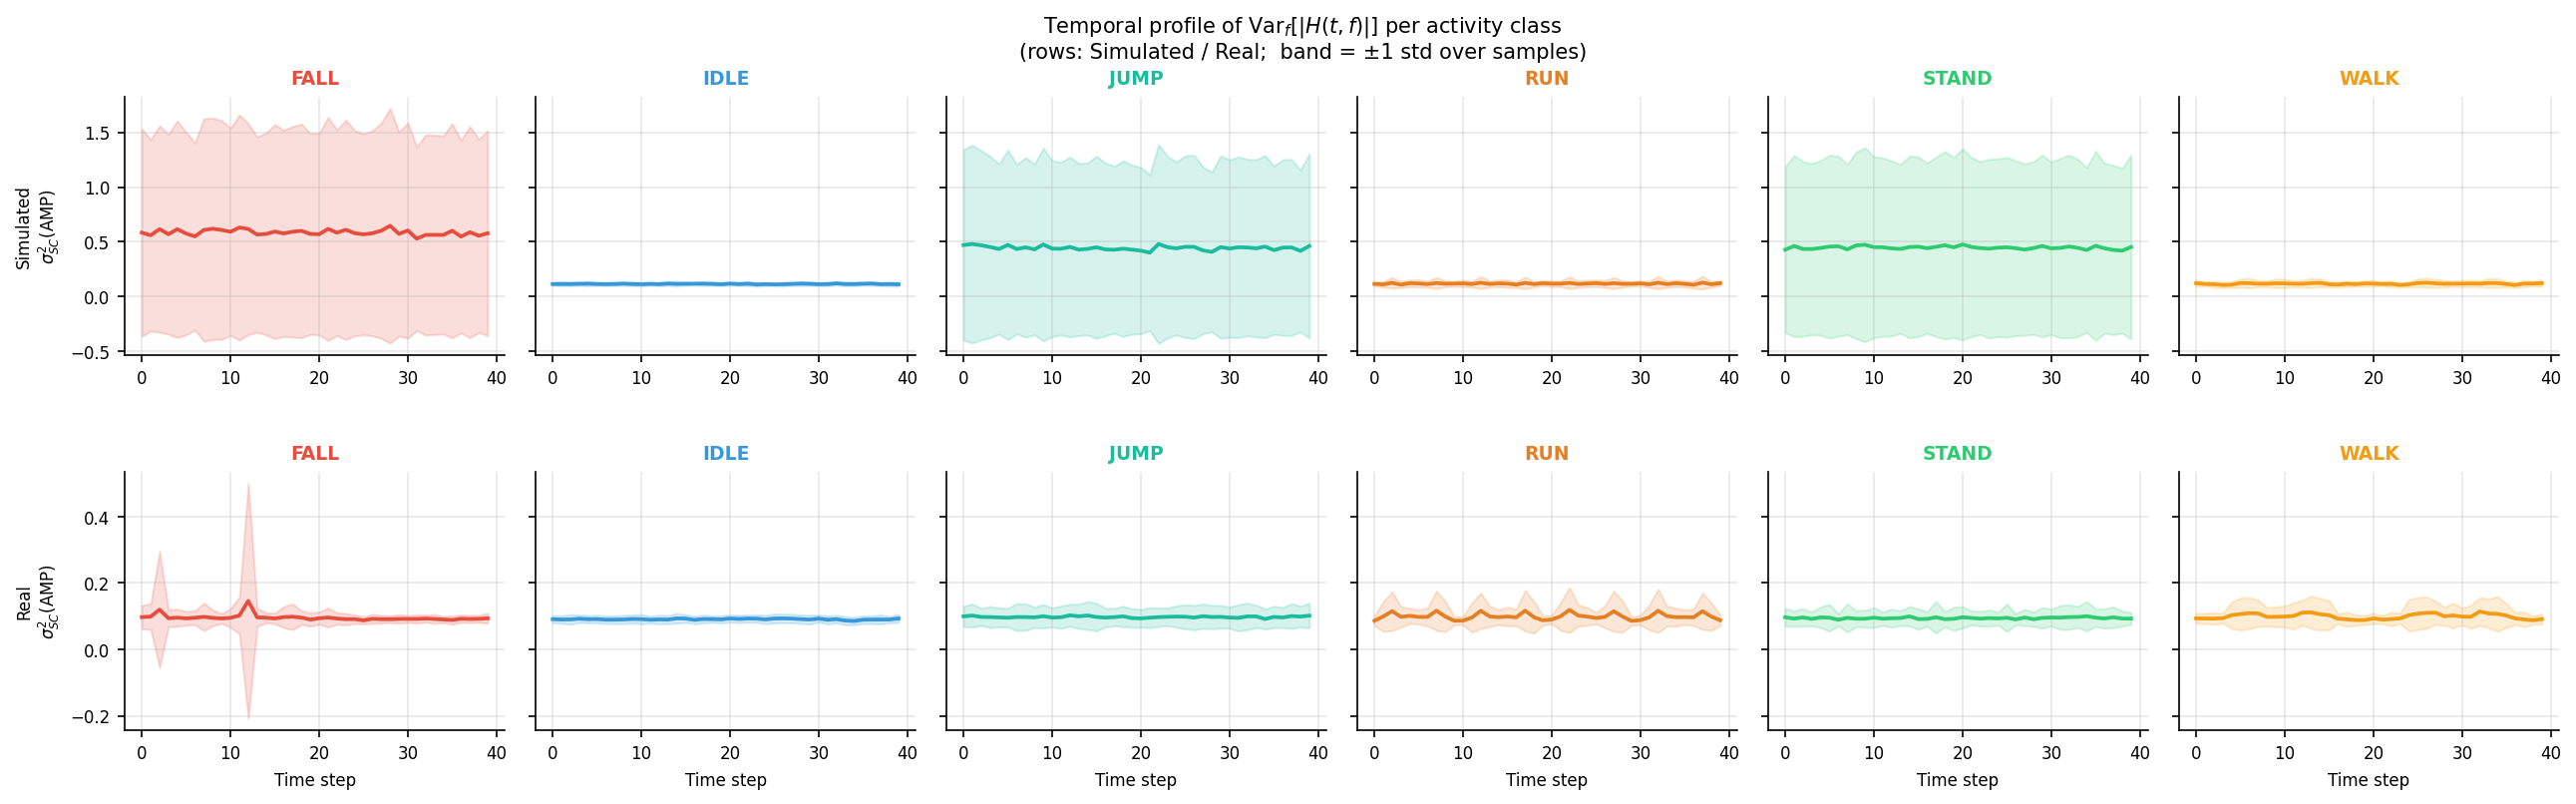

Saved → 10_temporal_var_profile.{png,pdf}  (→ paper Fig.14)


In [18]:

# ── 11. Temporal variance profile per class ──────────────────────────────────
t_ax = np.arange(X_sim.shape[1])
NC   = len(CLASSES)

fig, axes = plt.subplots(2, NC, figsize=(3.5 * NC, 5.5),
                         constrained_layout=False, sharey='row')
fig.subplots_adjust(hspace=0.45, wspace=0.08)

for row, (X, y, domain) in enumerate([
        (X_sim,  y_sim,  'Simulated'),
        (X_real, y_real, 'Real')]):
    for col, cls in enumerate(CLASSES):
        ax   = axes[row, col]
        mask = (y == cls)
        if not mask.any():
            ax.set_visible(False); continue
        AMP     = X[mask, :, :, 2].astype(np.float32)   # (N, T, SC)
        profile = AMP.var(axis=2)                         # (N, T)  var over SC
        mu      = profile.mean(axis=0)                   # (T,)
        sg      = profile.std(axis=0)                    # (T,)
        c = CLASS_COLORS[cls]
        ax.plot(t_ax, mu, color=c, linewidth=1.8)
        ax.fill_between(t_ax, mu - sg, mu + sg, color=c, alpha=0.18)
        ax.set_title(cls, color=c, fontweight='bold', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{domain}\n' + r'$\sigma^2_{SC}$(AMP)', fontsize=8)
        if row == 1:
            ax.set_xlabel('Time step', fontsize=8)

fig.suptitle(r'Temporal profile of $\mathrm{Var}_{f}[|H(t,f)|]$ per activity class'
             '\n(rows: Simulated / Real;  band = ±1 std over samples)', fontsize=10)

save_fig(fig, '10_temporal_var_profile')
plt.show()
plt.close()
print("Saved → 10_temporal_var_profile.{png,pdf}  (→ paper Fig.14)")
